# Find Hot & Cloudy days in Warm months (November to April) for Melbourne, Adelaide, Brisbane, Sydney, Hobart and Canberra
### A day is considered Hot and Cloudy if at least one hour between 10 am and 5 pm has a concurrent occurrence of CSI ≤ 0.5 and Temperature ≥ 90th percentile."

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
# import datetime as dt
import matplotlib.pyplot as plt
# import matplotlib.dates as mdates
#from IPython.display import Image

#import time

# set working directory
os.chdir("/g/data/fy29/sho561/Hot_Cloudy")
print("Current working directory:", os.getcwd())
DATA = Path("processed_csv")

Current working directory: /g/data/fy29/sho561/Hot_Cloudy


In [2]:
warm_months = [11, 12, 1, 2, 3, 4]
regions = ["GSYD", "GMEL", "GBRI","GADE", "GHOB", "ACTE"]
years = range(2015, 2024)


### Load hourly temperature (tas) data, and keep warm months and hours between 10 am and 5pm

In [3]:
def load_filter_convert_tas(region: str, year: int) -> pd.DataFrame:
    p = DATA / f"Alex_tas_{region}_{year}_AEST_C.csv"
    df = pd.read_csv(p, parse_dates=["time"], usecols=["time", "tas"])
    # Filter warm months
    df = df[df["time"].dt.month.isin(warm_months)]
    # Filter hours 10..17 inclusive
    hours = df["time"].dt.hour
    df = df[(hours >= 10) & (hours < 17)]
    
    # Add region and year for clarity
    df["region"] = region

    return df

# Dictionary to hold data by region
region_data_tas = {}

for region in regions:
    parts = []
    for year in years:
        parts.append(load_filter_convert_tas(region, year))
    region_data_tas[region] = pd.concat(parts, ignore_index=True).sort_values("time")

tas_syd = region_data_tas["GSYD"]
tas_syd.head(10)

,time,tas,region
0,2015-01-01 10:00:00,25.816198,GSYD
1,2015-01-01 11:00:00,27.780300,GSYD
2,2015-01-01 12:00:00,29.524407,GSYD
3,2015-01-01 13:00:00,30.726930,GSYD
4,2015-01-01 14:00:00,31.111994,GSYD
5,2015-01-01 15:00:00,30.793767,GSYD
6,2015-01-01 16:00:00,30.052731,GSYD
7,2015-01-02 10:00:00,23.932130,GSYD
8,2015-01-02 11:00:00,25.573917,GSYD
9,2015-01-02 12:00:00,27.144987,GSYD


### Load hourly capacity solar index (CSI) data, and keep warm months and hours between 10 am and 5pm

In [4]:
def load_filter_convert_csi(region: str, year: int) -> pd.DataFrame:
    p = DATA / f"Carl_Cloud_CSI_{region}_{year}_hourly_mean.csv"
    df = pd.read_csv(p, parse_dates=["time"], usecols=["time", "CSI"])
    # Filter warm months
    df = df[df["time"].dt.month.isin(warm_months)]
    # Filter hours 10..17 inclusive
    hours = df["time"].dt.hour
    df = df[(hours >= 10) & (hours < 17)]
   
    # Add region and year for clarity
    df["region"] = region

    return df

# Dictionary to hold data by region
region_data_csi = {}

for region in regions:
    parts = []
    for year in years:
        parts.append(load_filter_convert_csi(region, year))
    region_data_csi[region] = pd.concat(parts, ignore_index=True).sort_values("time")

csi_syd = region_data_csi["GSYD"]
csi_syd.head(10)

,time,CSI,region
0,2015-11-01 10:00:00,0.918246,GSYD
1,2015-11-01 11:00:00,0.885320,GSYD
2,2015-11-01 12:00:00,0.787794,GSYD
3,2015-11-01 13:00:00,0.717241,GSYD
4,2015-11-01 14:00:00,0.550907,GSYD
5,2015-11-01 15:00:00,0.257243,GSYD
6,2015-11-01 16:00:00,0.253807,GSYD
7,2015-11-02 10:00:00,0.864149,GSYD
8,2015-11-02 11:00:00,0.835910,GSYD
9,2015-11-02 12:00:00,0.768986,GSYD


## Compute 90th percentile for temperature (tas) for each region

In [5]:
tas_90p = {}

for region, df in region_data_tas.items():
    tas_90p[region] = df["tas"].quantile(0.9)

print(tas_90p)

{'GSYD': np.float64(29.908553286852634), 'GMEL': np.float64(28.260335776545173), 'GBRI': np.float64(31.139925219538984), 'GADE': np.float64(31.934703125000045), 'GHOB': np.float64(23.39605402542377), 'ACTE': np.float64(27.049671052631613)}


# Plot CSI vs tas

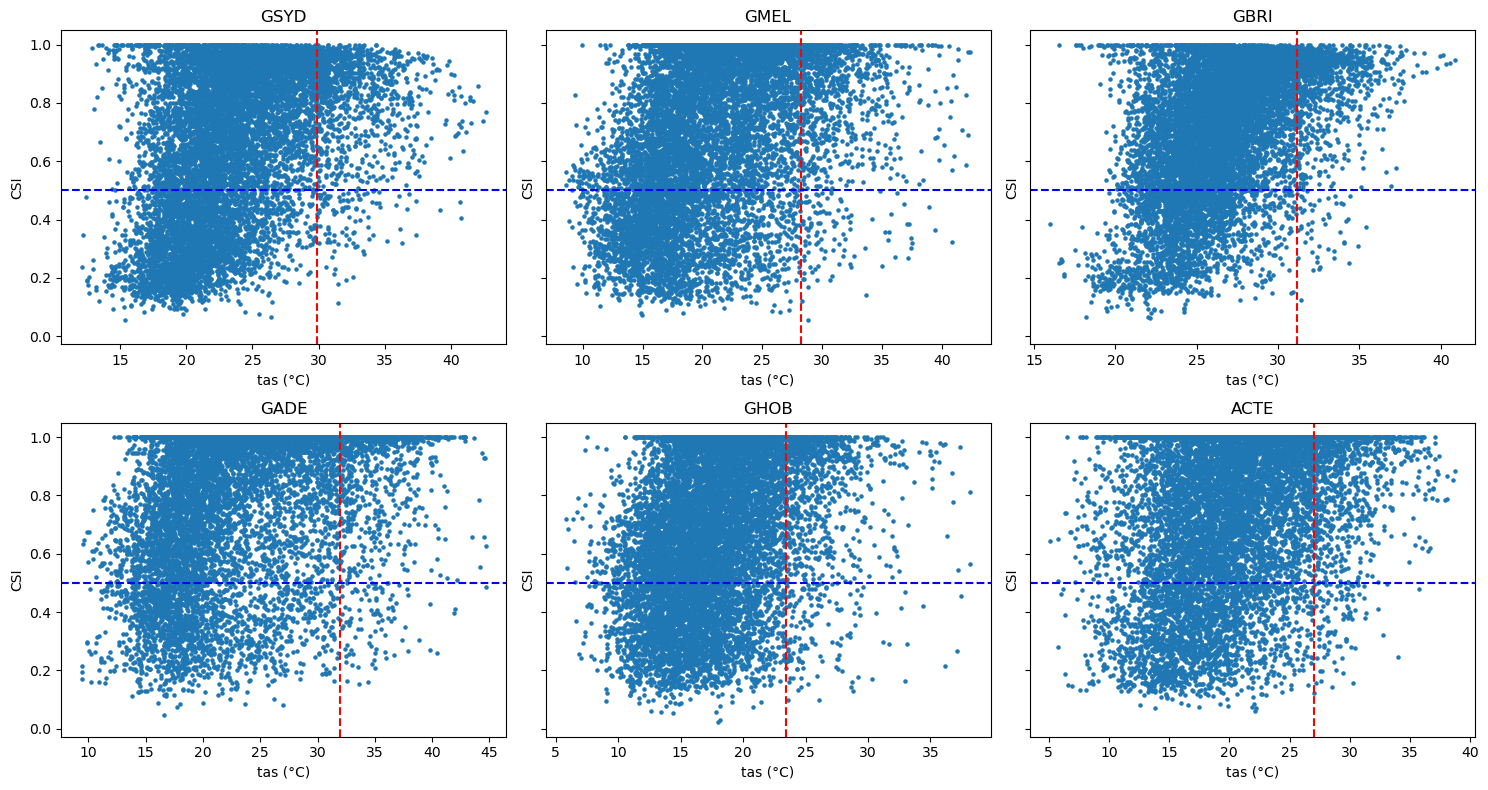

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)

for ax, region in zip(axes.ravel(), regions):
    df_tas = region_data_tas[region].copy()
    df_csi = region_data_csi[region].copy()

    # clip CSI > 1 to 1
    df_csi["CSI"] = df_csi["CSI"].clip(upper=1)

    # merge on time
    df = pd.merge(df_tas[["time", "tas"]], df_csi[["time", "CSI"]], on="time", how="inner")

    ax.scatter(df["tas"], df["CSI"], s=5)
    ax.axvline(tas_90p[region], color="red", linestyle="--")
    ax.axhline(0.5, color="blue", linestyle="--")
    ax.set_title(region)
    ax.set_xlabel("tas (°C)")
    ax.set_ylabel("CSI")

plt.tight_layout()
plt.show()



# Hot & Cloudy hours

In [7]:
filtered_data = []

for region in regions:
    df_tas = region_data_tas[region].copy()
    df_csi = region_data_csi[region].copy()

    # clip CSI > 1 to 1
    df_csi["CSI"] = df_csi["CSI"].clip(upper=1)

    # merge on time
    df = pd.merge(df_tas[["time", "tas"]], df_csi[["time", "CSI"]], on="time", how="inner")
    df["region"] = region

    # filter conditions
    df = df[(df["CSI"] <= 0.5) & (df["tas"] >= tas_90p[region])]

    filtered_data.append(df)

# final DataFrame
df_filtered = pd.concat(filtered_data, ignore_index=True)

# keep only needed columns
df_filtered = df_filtered[["time", "region"]]

display(df_filtered)

out_path = DATA / "event_times_csi0p5_thourly90.csv"
df_filtered.to_csv(out_path, index=True)

,time,region
0,2016-01-14 13:00:00,GSYD
1,2016-01-14 14:00:00,GSYD
2,2016-01-14 15:00:00,GSYD
3,2016-01-14 16:00:00,GSYD
4,2016-01-21 15:00:00,GSYD
...,...,...
594,2023-12-09 10:00:00,ACTE
595,2023-12-19 13:00:00,ACTE
596,2023-12-19 14:00:00,ACTE
597,2023-12-19 15:00:00,ACTE


# Hot & Cloudy days

In [8]:
# time as day, unique rows, reset index
df_filtered_day = df_filtered.copy()
df_filtered_day["time"] = pd.to_datetime(df_filtered_day["time"]).dt.date
df_filtered_day = df_filtered_day[["time", "region"]].drop_duplicates().reset_index(drop=True)

df_filtered_day

out_path = DATA / "event_dates_csi0p5_thourly90.csv"
df_filtered_day.to_csv(out_path, index=True)

## Daily maximum temperature

In [9]:
# daily maximum tas per region, time without hours
daily_max_tas = {}

for region in regions:
    df = region_data_tas[region].copy()
    df["date"] = df["time"].dt.normalize()  # strip hours
    out = df.groupby("date", as_index=False)["tas"].max()
    out = out.rename(columns={"date": "time", "tas": "tas_max"})
    daily_max_tas[region] = out

display(daily_max_tas["GSYD"].head())

tas_daily_90p = {}

for region in regions:
    df = daily_max_tas[region]
    tas_daily_90p[region] = df["tas_max"].quantile(0.9)

print(tas_daily_90p)



,time,tas_max
0,2015-01-01,31.111994
1,2015-01-02,28.187068
2,2015-01-03,31.352158
3,2015-01-04,31.444663
4,2015-01-05,22.231682


{'GSYD': 31.14129316069057, 'GMEL': 29.905739896988905, 'GBRI': 32.344803100987974, 'GADE': 33.814453125, 'GHOB': 24.913559322033905, 'ACTE': 28.23353207236846}


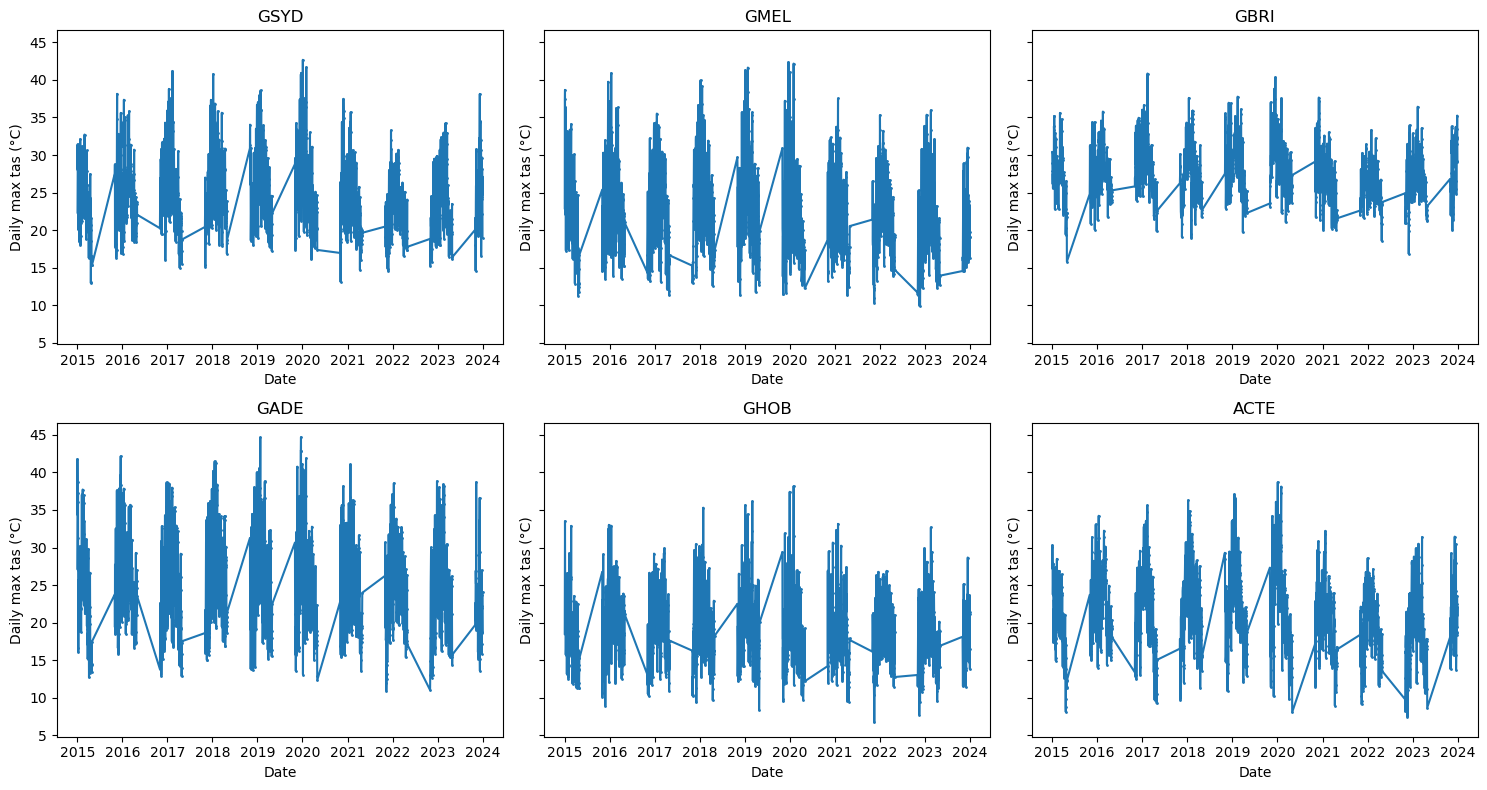

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)

for ax, region in zip(axes.ravel(), regions):
    df = daily_max_tas[region]
    ax.plot(df["time"], df["tas_max"], marker=".", linestyle="-", markersize=2)
    ax.set_title(region)
    ax.set_xlabel("Date")
    ax.set_ylabel("Daily max tas (°C)")

plt.tight_layout()
plt.show()


# Identify null-events 

### Null-events hours

In [7]:
filtered_data = []

for region in regions:
    df_tas = region_data_tas[region].copy()
    df_csi = region_data_csi[region].copy()

    # clip CSI > 1 to 1
    df_csi["CSI"] = df_csi["CSI"].clip(upper=1)

    # merge on time
    df = pd.merge(df_tas[["time", "tas"]], df_csi[["time", "CSI"]], on="time", how="inner")
    df["region"] = region

    # filter conditions
    df = df[(df["CSI"] > 0.5) & (df["tas"] >= tas_90p[region])]

    filtered_data.append(df)

# final DataFrame
df_filtered = pd.concat(filtered_data, ignore_index=True)

# keep only needed columns
df_filtered = df_filtered[["time", "region"]]

display(df_filtered)

out_path = DATA / "null_event_times_csi0p5_thourly90.csv"
df_filtered.to_csv(out_path, index=True)

,time,region
0,2015-11-18 12:00:00,GSYD
1,2015-11-18 13:00:00,GSYD
2,2015-11-18 14:00:00,GSYD
3,2015-11-18 15:00:00,GSYD
4,2015-11-18 16:00:00,GSYD
...,...,...
5874,2023-12-18 14:00:00,ACTE
5875,2023-12-18 15:00:00,ACTE
5876,2023-12-18 16:00:00,ACTE
5877,2023-12-19 11:00:00,ACTE


### Null-events days

In [10]:

# Count available hours per day per region, then keep days with nhours == 7, corresponding to all hours between 10 and 17

df_filtered_count_null = df_filtered.copy()
df_filtered_count_null["time"] = pd.to_datetime(df_filtered_count_null["time"])
df_filtered_count_null["date"] = df_filtered_count_null["time"].dt.date

df_filtered_count_null = (
    df_filtered_count_null
    .groupby(["date", "region"], as_index=False)
    .agg(nhours=("time", "count"))
    .rename(columns={"date": "time"})
)[["time", "region", "nhours"]]

df_filtered_count_null

# filter for exactly 7 hours
df_filtered_7h = df_filtered_count_null[df_filtered_count_null["nhours"] == 7].reset_index(drop=True)

# write out
out_path_7h = DATA / "null_event_dates_csi0p5_thourly90_nhours7.csv"
df_filtered_7h[["time", "region"]].to_csv(out_path_7h, index=True)

In [11]:
df_filtered_7h

,time,region,nhours
0,2015-11-18,GADE,7
1,2015-11-20,ACTE,7
2,2015-11-20,GSYD,7
3,2015-12-01,GSYD,7
4,2015-12-05,GADE,7
...,...,...,...
219,2023-11-10,GADE,7
220,2023-12-08,GSYD,7
221,2023-12-09,GSYD,7
222,2023-12-14,GSYD,7
